# Daily Specification for returns

**Pending to consider:**
- Global Oil Rig Countrs
- Interest Rates (10y Treasury)
- Refinery Spreads
- Speculative Trading Volum

The results point to a strongly state‑dependent structure in Brent return dynamics:

- GPR affects only the extremes, not the center of the distribution.

- Return persistence is asymmetric, with different lags becoming relevant depending on the quantile.

- The market exhibits heterogeneous responses to both geopolitical shocks and its own past behavior.

### Data importing 

In [1]:
# --- Libraries ---
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

import os 

# --- Configuration ---
wd = r"C:\Users\Alejandro\Documents\MQuEA\TFM\main_code"
os.chdir(wd)

from auxi.data import import_data, update_brent
import auxi.qreg as aux

In [2]:
data_daily = import_data(freq="Daily")

c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\data.py:353: DtypeWarning: Columns (40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  panel = pd.read_csv(csv_path, index_col=0, parse_dates=True)


In [3]:
data_daily["covid_dummy"]= np.where((data_daily.index == "2020-04-21"), 1, 0)
data_daily["GPRD_MA5"] = data_daily["GPRD"].rolling(window=5).mean()
data_daily["GPRD_MA14"] = data_daily["GPRD"].rolling(window=14).mean()
data_daily["l_GPRD"] = np.log(data_daily["GPRD"])
data_daily["GPRD^2"] = data_daily["GPRD"]**2
data_daily["usdi_abs"] = np.abs(data_daily["usd_index_ld"])


c:\Users\Alejandro\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
data_daily["Brent_Return_MA5"] = data_daily["Brent_Return"].rolling(window=5).mean()
data_daily["Brent_Return_MA30"] = data_daily["Brent_Return"].rolling(window=30).mean()
data_daily["Brent_Return_MA90"] = data_daily["Brent_Return"].rolling(window=90).mean()


### Autocorrelogram

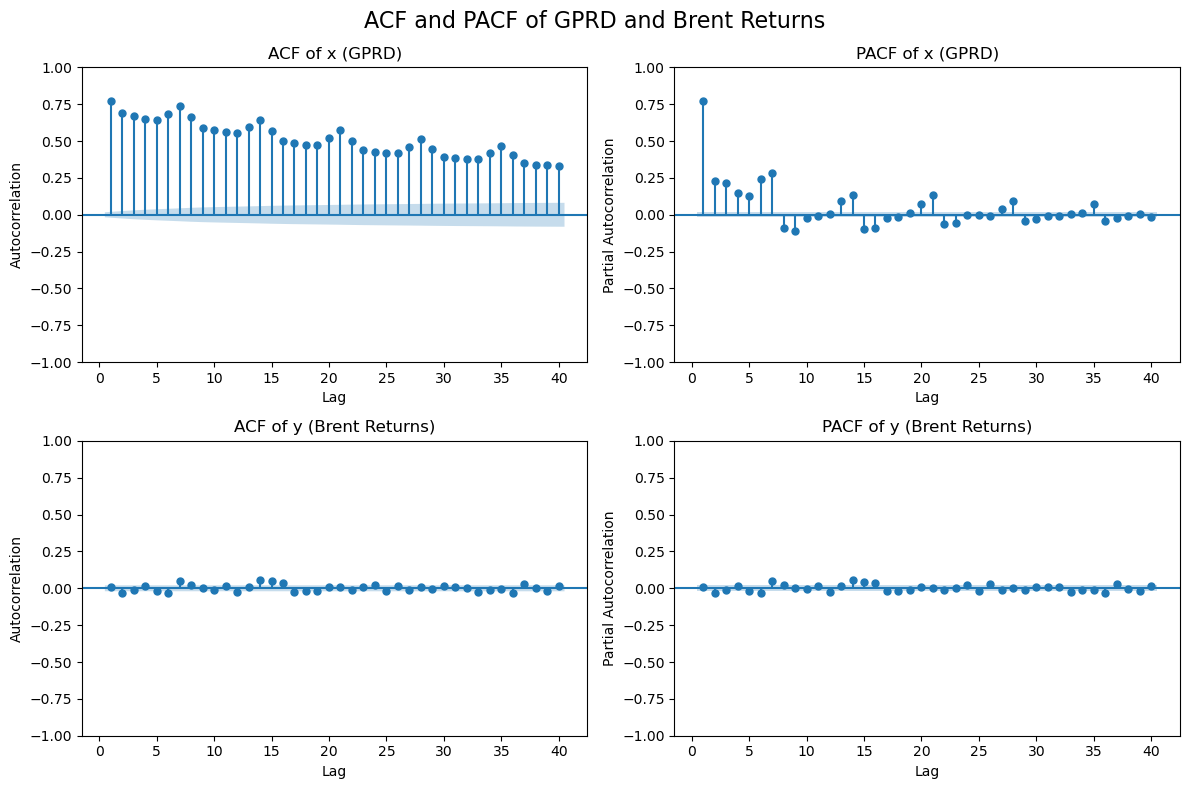

In [5]:
# Define variables x and y
x = data_daily["GPRD"]
y = data_daily["Brent_Return"]

# Create a 2x2 subplot for ACF and PACF
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle('ACF and PACF of GPRD and Brent Returns', fontsize=16)
# ACF of x
sm.graphics.tsa.plot_acf(x.dropna(), lags=np.arange(1, 41), ax=ax[0, 0], title='ACF of x (GPRD)')
ax[0, 0].set_xlabel('Lag')
ax[0, 0].set_ylabel('Autocorrelation')

# PACF of x
sm.graphics.tsa.plot_pacf(x.dropna(), lags=np.arange(1, 41), ax=ax[0, 1], title='PACF of x (GPRD)')
ax[0, 1].set_xlabel('Lag')
ax[0, 1].set_ylabel('Partial Autocorrelation')

# ACF of y
sm.graphics.tsa.plot_acf(y.dropna(), lags=np.arange(1, 41), ax=ax[1, 0], title='ACF of y (Brent Returns)')
ax[1, 0].set_xlabel('Lag')
ax[1, 0].set_ylabel('Autocorrelation')

# PACF of y
sm.graphics.tsa.plot_pacf(y.dropna(), lags=np.arange(1, 41), ax=ax[1, 1], title='PACF of y (Brent Returns)')
ax[1, 1].set_xlabel('Lag')
ax[1, 1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

### Chosen specification

The results obtained in Zheng et al. are presented below:

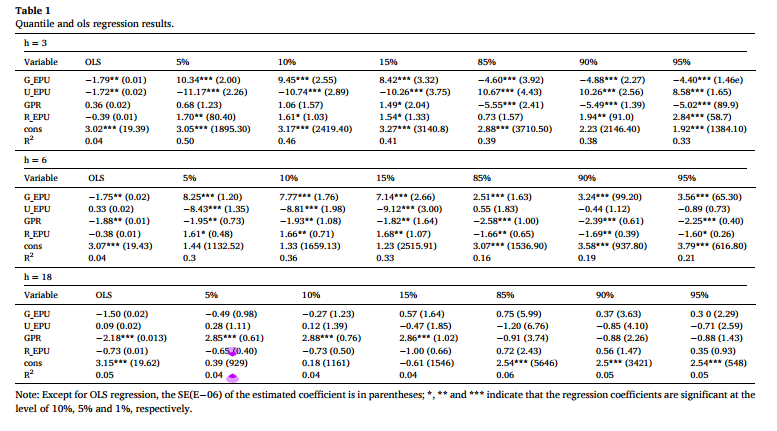

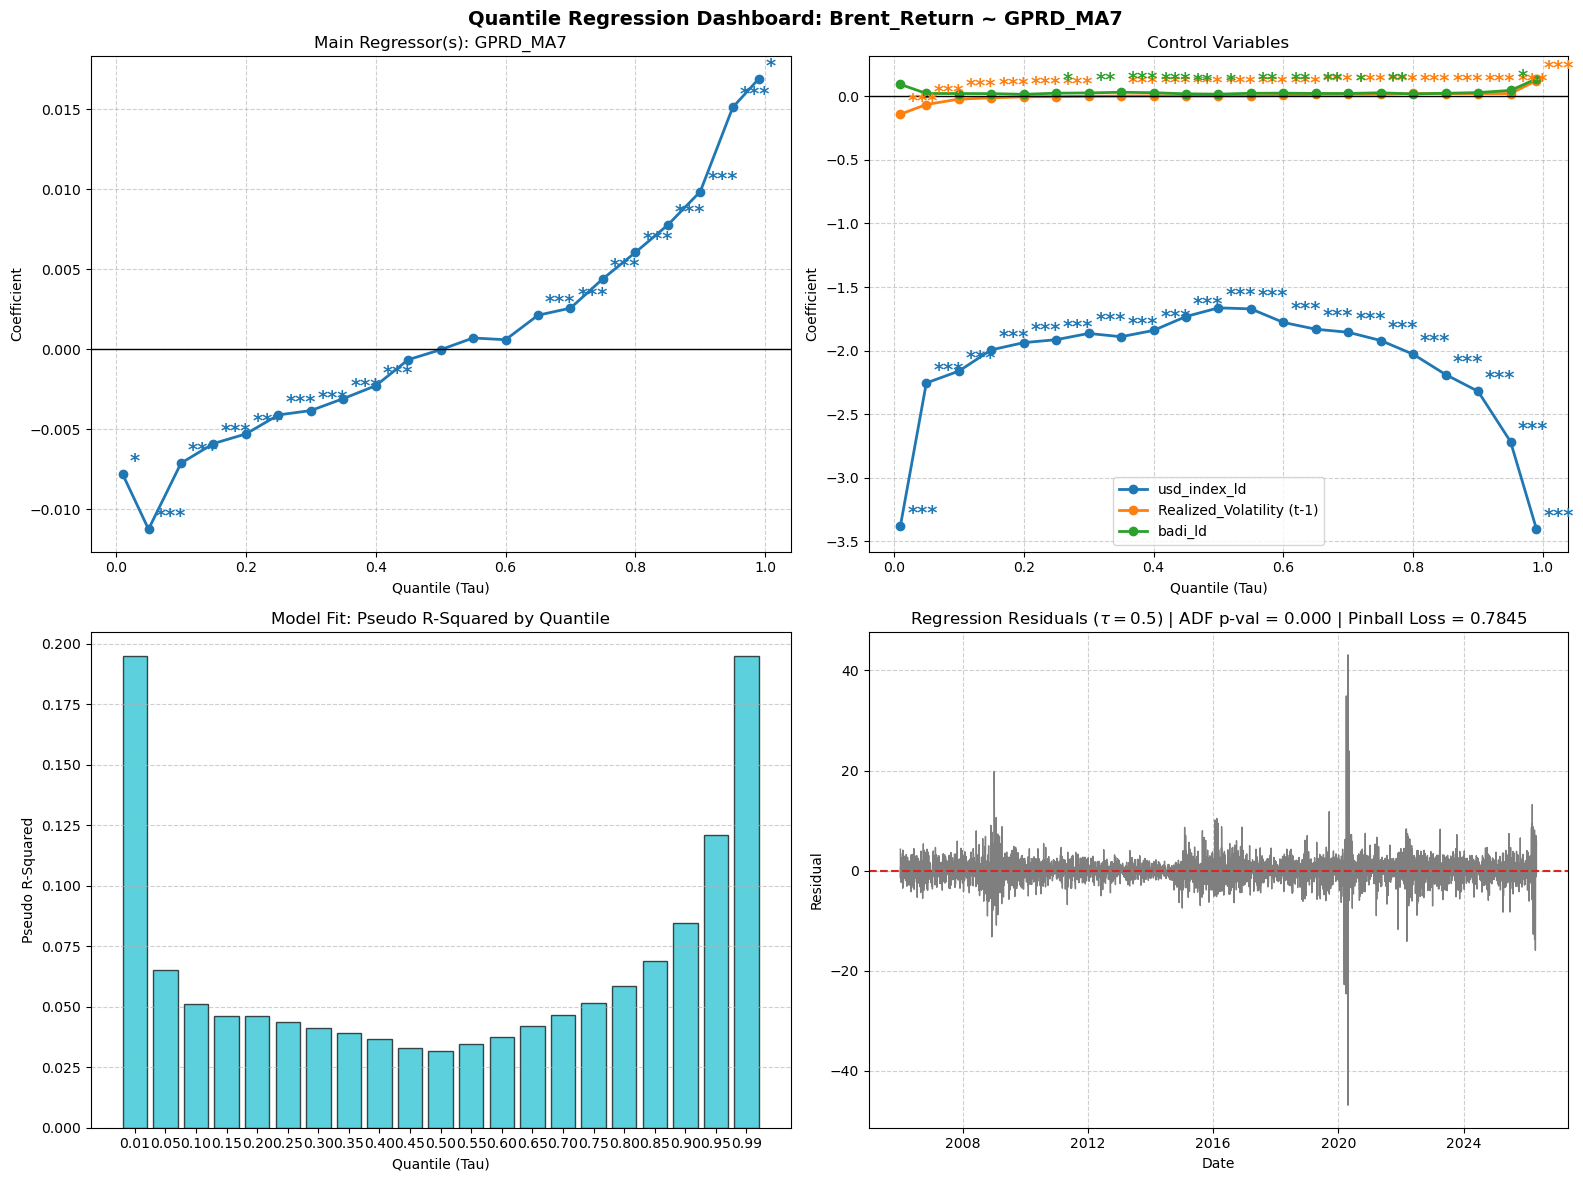

In [5]:
control_vars =["usd_index_ld", "Realized_Volatility (t-1)", "badi_ld"] 
# Displays the plots and stores the dataframe
my_table = aux.plot_quantile_results(
    data=data_daily,
    vars_x="GPRD_MA7",
    vars_y="Brent_Return", 
    controls = control_vars
)

In [7]:
my_table[my_table["Tau"].isin([0.05, 0.5, 0.95])]

,Dependent Variable,Regressor,Tau,Coefficient,Significance,Pseudo R-Squared
1,Brent_Return,GPRD_MA7,0.05,-0.000275,,0.531477
10,Brent_Return,GPRD_MA7,0.50,-0.000200,,0.033899
19,Brent_Return,GPRD_MA7,0.95,0.000163,,0.559097
22,Brent_Return,Realized_Volatility,0.05,-0.187220,***,0.531477
31,Brent_Return,Realized_Volatility,0.50,0.019630,***,0.033899
40,Brent_Return,Realized_Volatility,0.95,0.187130,***,0.559097
43,Brent_Return,badi_ld,0.05,0.001257,,0.531477
52,Brent_Return,badi_ld,0.50,0.015345,,0.033899
61,Brent_Return,badi_ld,0.95,0.000103,,0.559097
64,Brent_Return,usd_index_ld,0.05,-0.092836,***,0.531477


## CAViaR Spec.

Sobre la **especificacion seleccionada** (la misma de *Chosen specification*) anadimos dos variables indicador binarias estilo CAViaR (Engle & Manganelli, 2004):

- `upside_breach`   = 1 si el retorno realizado supera la frontera cuantilica alta.
- `downside_breach` = 1 si queda por debajo de la frontera cuantilica baja.

Las fronteras se ajustan **in-sample** con la propia especificacion, usando sus **cuantiles extremos** (`breach_quantiles`). Los indicadores se incorporan como regresores adicionales en la regresion cuantilica.

El interes aqui es puramente **explicativo**: ver como el estado de breach desplaza cada cuantil condicional del retorno. Existe *look-ahead* en todas las variables (incluidos los indicadores, ajustados sobre toda la muestra); es aceptable en esta fase descriptiva. El esquema sin look-ahead usa `compute_breach_indicators(h=...)` y se implementa en `direct_forecasting.ipynb`.

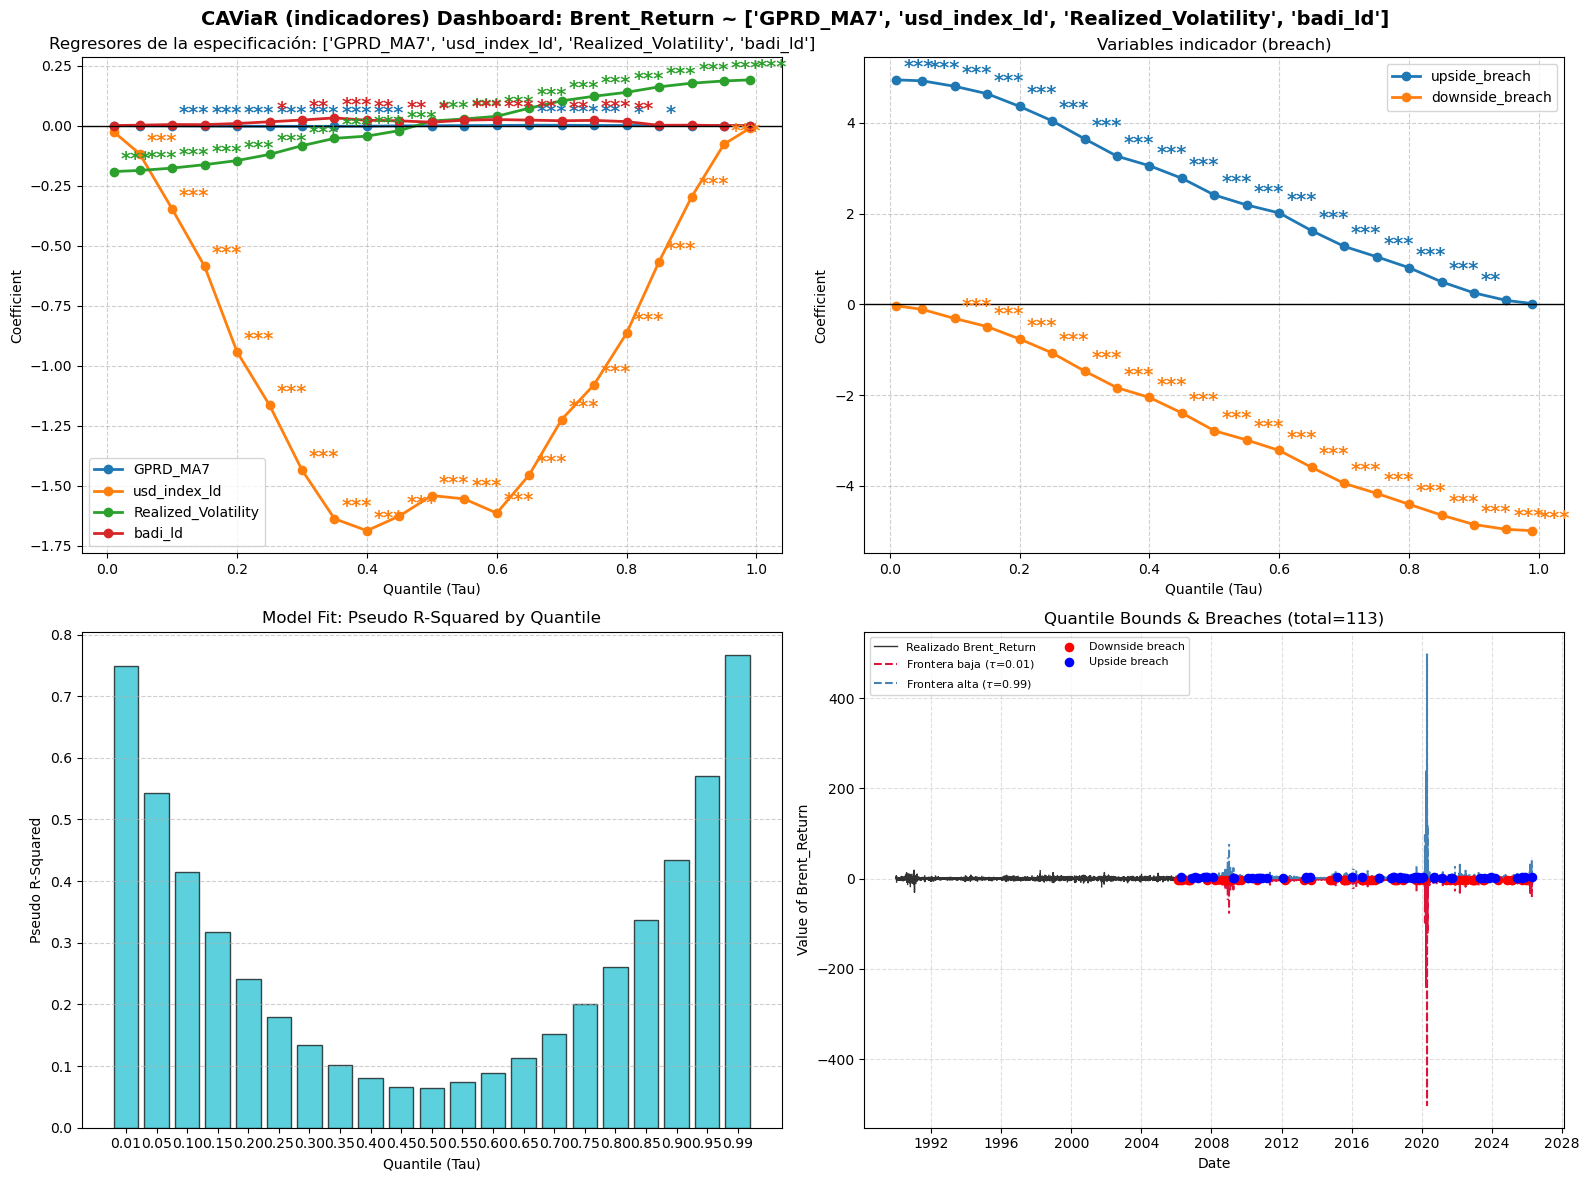

In [7]:
import auxi.caviar as caviar

# Especificacion seleccionada (identica a 'Chosen specification'):
# vars_x recoge TODA la especificacion, porque las fronteras del breach se
# ajustan in-sample con la misma spec.
caviar_spec = ["GPRD_MA7", "usd_index_ld", "Realized_Volatility",
               "badi_ld"]

# Dashboard CAViaR con indicadores.
# breach_quantiles = cuantiles extremos de la especificacion (definen el breach).
caviar_table = caviar.plot_caviar_i_results(
    data=data_daily,
    vars_x=caviar_spec,
    vars_y="Brent_Return",
    breach_quantiles=[0.01, 0.99],
)


# In-sample diagnosis


In [22]:
import auxi.diagnostics as diags

### Multicolinearity


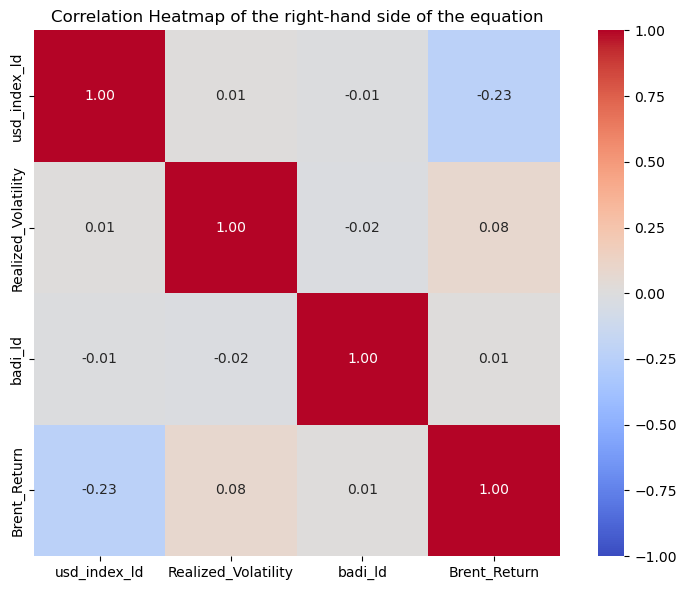

In [43]:


variables =["usd_index_ld", "Realized_Volatility", "badi_ld","Brent_Return"] 
df_vars = data_daily[variables].dropna()

corr = df_vars.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap of the right-hand side of the equation")
plt.tight_layout()
plt.show()

In [44]:
corr

,usd_index_ld,Realized_Volatility,badi_ld,Brent_Return
usd_index_ld,1.000000,0.014489,-0.012937,-0.228451
Realized_Volatility,0.014489,1.000000,-0.017668,0.082138
badi_ld,-0.012937,-0.017668,1.000000,0.011974
Brent_Return,-0.228451,0.082138,0.011974,1.000000


### DQ Test



**Note on Empirical Specification:** Through rigorous empirical testing, it has been determined that the only way our dynamic specification can systematically pass the DQ test across all quantiles is by explicitly controlling for the square of the returns. Including this proxy for volatility is essential to fully capture the conditional heteroskedasticity and the dynamic memory of the series, ensuring that no residual time-structure is left in the tails.

**The test**

Following **Engle and Manganelli (2004)**, standard residuals are meaningless in a Quantile Autoregression (QAR) framework. Instead, we evaluate the dynamic specification of the model by testing the **"Hits"** sequence.

The baseline theorem states that if a dynamic quantile model is perfectly specified, the sequence of Hits—which tracks when the observed value exceeds or falls below the predicted quantile—must behave as a **martingale difference (pure white noise)**.

We define the Hit sequence as an indicator function:

$$\text{Hit}_t(\tau) =
\begin{cases}
1 - \tau, & \text{if } Y_t < \hat Y_t(\tau) \\
-\tau, & \text{if } Y_t \ge \hat Y_t(\tau)
\end{cases}$$

*Intuition:* If we run a quantile regression at $\tau = 0.10$, the model should leave exactly 10% of the data below the predicted line. More importantly, the *timing* of these violations must be completely unpredictable. A sequence of consecutive violations indicates that the model is failing to capture momentum or volatility clustering.

**Hypotheses**

The DQ test evaluates whether the Hits are correlated with any past information available in the information set ($\Omega_{t-1}$).

* **Null Hypothesis ($H_0$):** $E[\text{Hit}_t(\tau) | \Omega_{t-1}] = 0$
Under $H_0$, the Hit sequence is pure white noise. The violations of the quantile are completely random and exhibit no time structure.
* **Alternative Hypothesis ($H_1$):** $E[\text{Hit}_t(\tau) | \Omega_{t-1}] \ne 0$

**Goal:** Unlike many significance tests, our objective here is to **fail to reject the null hypothesis** (i.e., achieve a p-value > 0.05), confirming that the hits are completely random.

**3. Practical Implementation**

The DQ statistic is constructed via an artificial OLS regression of the Hits against a matrix of instruments, $X_t$.

**Step 1: Run the Quantile Regression**
Estimate the model at the desired $\tau$ and extract the fitted values ($\hat Y_t$).

**Step 2: Construct the Hits Series**
Generate the binary Hit variable using the formula described above.

**Step 3: Define the Instrument Matrix ($X_t$)**
The selection of instruments is a "stress-test" for the model. We typically include:

* **A Constant:** To unconditionally evaluate if the proportion of hits matches the estimated quantile $\tau$.
* **The Fitted Values ($\hat Y_t$):** To check if the probability of observing a hit depends on the magnitude of the estimation (i.e., verifying if the model systematically overpredicts or underpredicts during high volatility periods).
* **Lags of the Hits:** Engle and Manganelli recommend using the first 4 lags ($\text{Hit}_{t-1}$ to $\text{Hit}_{t-4}$) to explicitly test for autocorrelation in the quantile violations.
* **Additional Controls (Optional but recommended):** * *Lags of the dependent variable ($Y_{t-1}$):* To verify the parametric model has extracted all predictive power from its own past.
* *Volatility proxies:* Such as rolling standard deviations, GARCH estimates, or **squared returns**, to ensure the conditional variance is fully captured.



*(Note: When running in-sample diagnostics, the constant and the fitted values are sometimes excluded to avoid perfect collinearity issues with the regression's gradient matrix).*

**Step 4: Run the Auxiliary OLS Regression**
Regress the Hit sequence on the instrument matrix to obtain the $R^2$:

$$\text{Hits}_t(\tau) = \gamma X_t + \epsilon_t \implies \text{obtain } R^2$$

**Step 5: Calculate the DQ Statistic**
The test statistic is simply the uncentered $R^2$ multiplied by the number of observations ($N$). Under the null hypothesis of correct specification, it follows a Chi-square distribution where $q$ is the number of instruments (columns in $X_t$):

$$DQ = N \cdot R^2 \sim \chi^2(q)$$

OLS AUXILIARY REGRESSION (Instrument Significance Checking):
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Constant               0.0014      0.002      0.765      0.444      -0.002       0.005
Y_pred                 0.0001      0.000      0.758      0.448      -0.000       0.001
Hit_lag_1              0.0256      0.015      1.699      0.089      -0.004       0.055
Hit_lag_2              0.0446      0.014      3.179      0.001       0.017       0.072
Hit_lag_3              0.0063      0.014      0.457      0.648      -0.021       0.033
Hit_lag_4              0.0058      0.014      0.422      0.673      -0.021       0.033
Brent_Return (t-1) -7.379e-05      0.001     -0.128      0.898      -0.001       0.001


NameError: name 'plot_pacf' is not defined

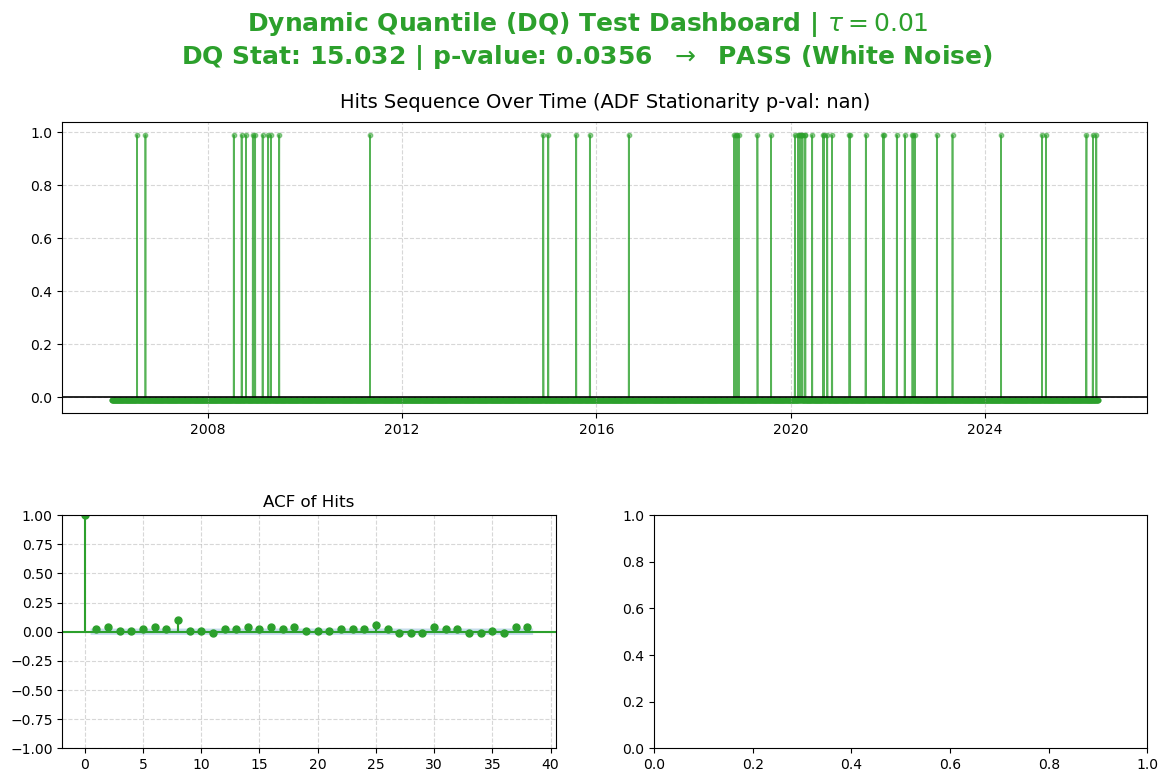

In [46]:
control_vars =["usd_index_ld", "Realized_Volatility (t-1)","badi_ld"] 

dq_results = diags.dq_test(df = data_daily, 
                         x="GPRD_MA5", 
                         y='Brent_Return', 
                         tau=0.01, 
                         controls= control_vars,
                         extra_instruments= ["Brent_Return (t-1)"] 
                        )

diags.plot_advanced_dq_diagnostics(dq_results)

### Koenker and Basset Wald test

This test evaluates the null hypothesis of symmetry—that is, whether the estimated coefficient of a specific regressor remains statistically equal across different quantiles of the distribution (e.g., the 5th percentile versus the 50th percentile). A rejection of the null hypothesis empirically proves that the variable exerts a fundamentally different impact during extreme market downturns compared to normal market conditions.

Constructing the Wald statistic requires an accurate estimation of the joint covariance matrix of the coefficients. Because our data exhibits strong temporal dependence, standard analytical sparsity estimators are invalid. To solve this, we estimate the joint variance using a Moving Block Bootstrap (MBB). Unlike a standard bootstrap, which draws individual observations randomly and destroys the chronological memory of the data, the MBB resamples continuous, overlapping "blocks" of time. This guarantees that the autoregressive properties and the conditional heteroskedasticity of the series are perfectly preserved within each drawn sequence.

The accuracy of the MBB relies heavily on the choice of the block size ($b$). Following the asymptotic theory for variance estimation in dependent time series established by Hall, Horowitz, and Jing (1995) and Politis and White (2004), the optimal block size grows proportionally to $T^{1/3}$. Given our sample of daily observations, this yields a theoretical optimal size of approximately 14 to 15 days. Consequently, we fix the block size at $b = 15$, which aligns elegantly with the empirical standard of exactly three weeks of trading. This specific window provides an optimal balance for Brent crude returns: it is sufficiently long to preserve the short-term volatility clustering and the memory of geopolitical shocks without sacrificing the randomness (entropy) required for a robust bootstrap distribution.

Starting Wald Test (tau1=0.99 vs tau2=0.9)...


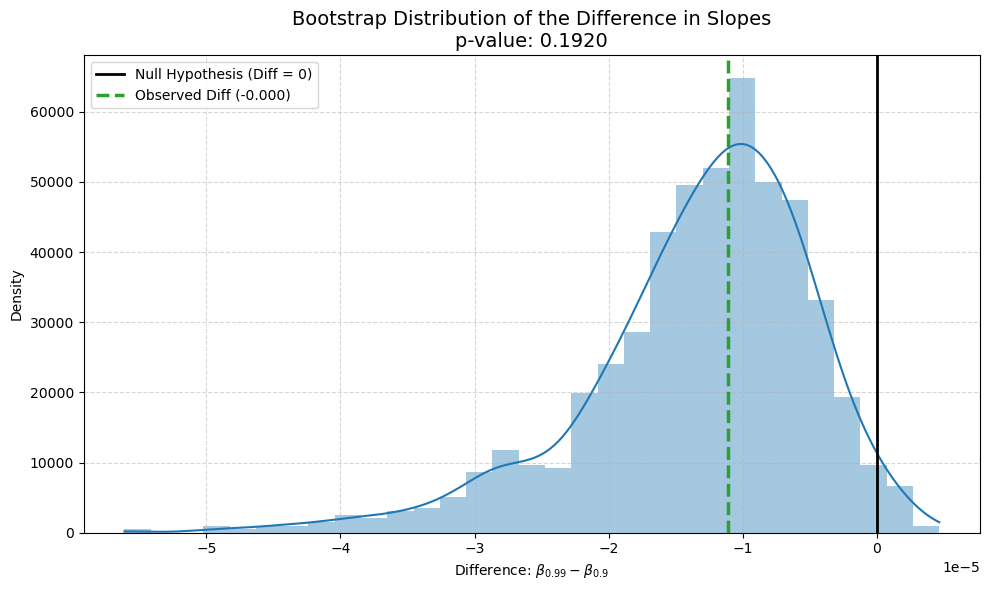

In [ ]:
control_vars = ["usd_index_ld","Brent_Abs_Return (t-1)", "Realized_Volatility_MA2", "REIA_fd" , "us_weekly_stocks_ld", "badi_ld"] 


resultados_wald = diags.wald_test(df=data_daily, 
                                x="GPRD_MA7", 
                                y="Brent_Return", 
                                tau1=0.99, 
                                tau2=0.9, 
                                controls= control_vars, 
                                n_bootstraps=1000, 
                                block_size=7) 

# Desplegar el reporte visual
diags.plot_wald_diagnostics(resultados_wald)

### Stability (Unit root) test

Note, Koener and Xiao (2004) prove that a QAR model estimated at the median ($\tau$ = 0.5), allows t-statistic to converge to a DF distribution, therefore evaluating the 
𝑡-statistic against  −2.86 (the 5% critical value in the ADF statistic) is mathematically correct for the median regression. 

However, in quantile econometrics, the asymptotic distribution of the Dickey–Fuller statistic in depends on nuisance parameters related to the cross‑density of the underlying distribution.

In [ ]:
control_vars =["usd_index_ld","Brent_Abs_Return (t-1)", "Realized_Volatility_MA2", "REIA_fd","natgas_spotprice_ld", "GPRD_MA5"] 
diags.qarx_stability_test(data_daily, y_col='Brent_Return', x_cols=control_vars, tau=0.9, lags=1)

{'Tau': 0.9,
 'Rho': -1.0584604369161994,
 't_stat': -70.89871183762787,
 'is_stable': True,
 'model_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                          QuantReg Regression Results                          
 Dep. Variable:                Q('dy')   Pseudo R-squared:               0.5340
 Model:                       QuantReg   Bandwidth:                    0.004738
 Method:                 Least Squares   Sparsity:                      0.05133
 Date:                Sat, 06 Jun 2026   No. Observations:                 2872
 Time:                        13:32:56   Df Residuals:                     2863
                                         Df Model:                            8
                                    coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------------------------------------------------------------
 Intercept                        0.0182      0.001     23.883      0.000       0.01

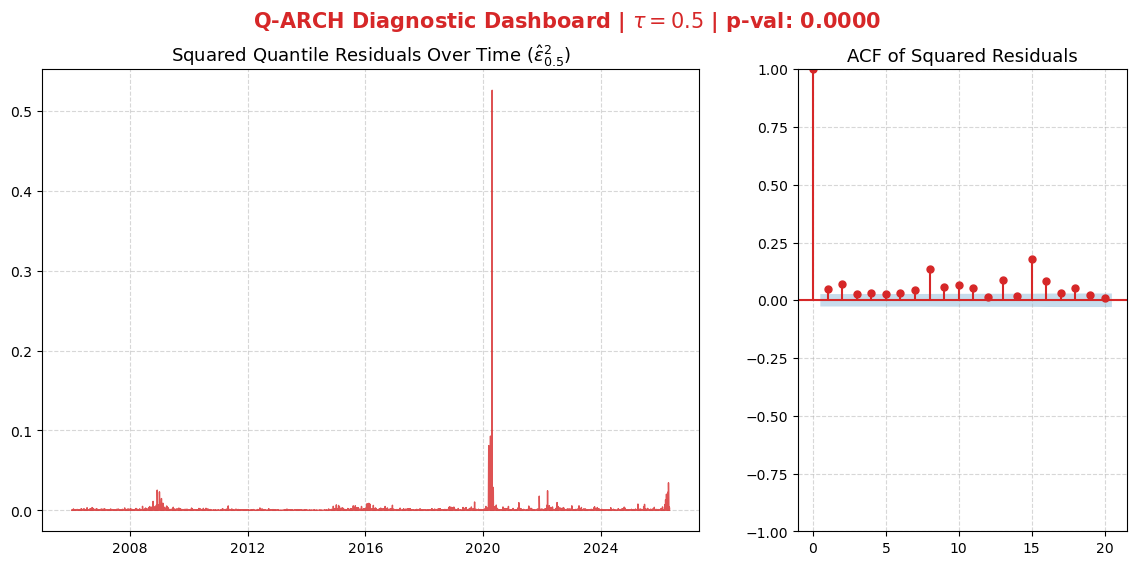

In [ ]:
control_vars =["usd_index_pct","Brent_Abs_Return (t-1)", "Realized_Volatility_MA2"]

arch_diag = diags.q_arch_test(df=data_daily, 
                            x="GPRD_MA7", 
                            y="Brent_Return", 
                            tau=0.5, 
                            controls=control_vars)


diags.plot_q_arch_diagnostics(arch_diag)



### Diagnosis on the model

[] It is impossible i have exaclty the same number of data at every quantile.
[] Q-Q plot of the data (residuasl too??)
[] Quantile function plot

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Density of Brent Returns
average = data_daily["Brent (Returns)"].mean()
median = data_daily["Brent (Returns)"].median()
q_05 = data_daily["Brent (Returns)"].quantile(0.05)
q_95 = data_daily["Brent (Returns)"].quantile(0.95)

rng = np.random.default_rng(seed=42)
normal_data = rng.normal(loc=average, scale=data_daily["Brent (Returns)"].std(), size=data_daily.shape[0])

ax1.hist(data_daily["Brent (Returns)"], bins=350, alpha=0.25, color='blue', density=True)
sns.kdeplot(normal_data, color='lightcoral', label='Normal Distribution', ax=ax1)
ax1.vlines(average, ymin=0, ymax=ax1.get_ylim()[1], color='red', linestyle='--', linewidth=2, label='Average')
ax1.vlines(median, ymin=0, ymax=ax1.get_ylim()[1], color='green', linestyle='--', linewidth=2, label='Median')
ax1.vlines(q_05, ymin=0, ymax=ax1.get_ylim()[1], color='orange', linestyle='--', linewidth=2, label='5th Percentile')
ax1.vlines(q_95, ymin=0, ymax=ax1.get_ylim()[1], color='purple', linestyle='--', linewidth=2, label='95th Percentile')
ax1.set_ylabel("Density")
ax1.set_title("Density of the Brent Returns")
ax1.set_xlim(-0.1, 0.1)
ax1.legend()

# Right plot: Number of Observations in Each Quantile Interval
quantiles = np.arange(0.1, 1.0, 0.1)
quantile_values = data_daily["Brent (Returns)"].quantile(quantiles)
bins = [-np.inf] + quantile_values.tolist() + [np.inf]
binned = pd.cut(data_daily["Brent (Returns)"], bins=bins, labels=[f'Q{i/100:.2f}' for i in range(10, 100, 10)] + ['Q0.9+'])
counts = binned.value_counts().sort_index()

counts.plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_title('Number of Observations in Each Quantile Interval')
ax2.set_xlabel('Quantile Interval')
ax2.set_ylabel('Number of Observations')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()